In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
housing = pd.read_csv('../datasets/housing.csv')

In [3]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Exploratory Data Analysis

- Print 
    - shape
    - columns
    - data types
- Univariate analysis
    - Descriptive Statistics
    - boxplot
    - histogram
- Bivariate
    - scatter plot
    - Pairplot
    - Correlation plot

# Option 01:
Manual EDA

# Option 02:
`ydata_profiling`

# Option 03:
`dtale`

In [4]:
from ydata_profiling import ProfileReport

In [5]:
profile = ProfileReport(housing, title='Housing Data Profiling Report')
profile.to_file("../data_reports/housing_data_profiling.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
import dtale

In [9]:
d = dtale.show(housing)
d.open_browser()

/mnt/data/miniconda3/envs/misl/lib/python3.10/site-packages/dtale/views.py:2145: FutureWarning:

The default value of regex will change from True to False in a future version.

2024-03-22 15:29:39,800 - ERROR    - Exception occurred while processing request: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
Traceback (most recent call last):
  File "/mnt/data/miniconda3/envs/misl/lib/python3.10/site-packages/dtale/views.py", line 119, in _handle_exceptions
    return func(*args, **kwargs)
  File "/mnt/data/miniconda3/envs/misl/lib/python3.10/site-packages/dtale/views.py", line 3135, in get_column_analysis
    return jsonify(**analysis.build())
  File "/mnt/data/miniconda3/envs/misl/lib/python3.10/site-packages/dtale/column_analysis.py", line 141, in build
    return_data, code = self.analysis.build(self)
  File "/mnt/data/miniconda3/envs/misl/lib/python3.10/site-packages/dtale/col

In [10]:
d.kill()

2024-03-22 15:33:51,993 - INFO     - Executing shutdown...
2024-03-22 15:33:51,994 - INFO     - Not running with the Werkzeug Server, exiting by searching gc for BaseWSGIServer
2024-03-22 15:33:52,058 - ERROR    - weakly-referenced object no longer exists
2024-03-22 15:33:52,068 - ERROR    - weakly-referenced object no longer exists
2024-03-22 15:33:52,069 - ERROR    - weakly-referenced object no longer exists
2024-03-22 15:33:52,070 - ERROR    - weakly-referenced object no longer exists


# Create train test

In [11]:
from sklearn.model_selection import train_test_split

# Random split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

print(f"Rows in train set: {len(train_set)}\nRows in test set: {len(test_set)}")

Rows in train set: 16512
Rows in test set: 4128


In [13]:
housing['median_income'].describe()

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: median_income, dtype: float64

In [15]:
housing['income_cat'] = pd.cut(housing['median_income'], 
       bins=[0., 1.5, 3.0, 4.5, 6., np.inf], 
       labels=[1, 2, 3, 4, 5])

housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3


In [17]:
len(housing)

20640

In [19]:
housing['income_cat'].value_counts() / len(housing) * 100

3    35.058140
2    31.884690
4    17.630814
5    11.443798
1     3.982558
Name: income_cat, dtype: float64

In [21]:
strat_train_set, strat_test_set = train_test_split(housing, 
                                                   test_size=0.2, 
                                                   random_state=42, 
                                                   stratify=housing['income_cat'])

In [22]:
def income_cat_proportions(data):
    return data['income_cat'].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, random_state=42, stratify=housing['income_cat'])

compare_props = pd.DataFrame({
    'Overall': income_cat_proportions(housing),
    'Stratified': income_cat_proportions(strat_test_set),
    'Random': income_cat_proportions(test_set),
}).sort_index()

compare_props['Rand. %error'] = 100 * compare_props['Random'] / compare_props['Overall'] - 100
compare_props['Strat. %error'] = 100 * compare_props['Stratified'] / compare_props['Overall'] - 100

compare_props

,Overall,Stratified,Random,Rand. %error,Strat. %error
1,0.039826,0.039971,0.040213,0.973236,0.364964
2,0.318847,0.318798,0.324370,1.732260,-0.015195
3,0.350581,0.350533,0.358527,2.266446,-0.013820
4,0.176308,0.176357,0.167393,-5.056334,0.027480
5,0.114438,0.114341,0.109496,-4.318374,-0.084674


In [24]:
# axis=0 means drop the row
# axis=1 means drop the column
housing = strat_train_set.drop(['median_house_value'], axis=1)
housing_labels = strat_train_set['median_house_value'].copy()

In [25]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND,2
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN,5
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND,2
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN,2
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN,3


In [26]:
housing_labels.head()

12655     72100.0
15502    279600.0
2908      82700.0
14053    112500.0
20496    238300.0
Name: median_house_value, dtype: float64

# Data Preprocessing

## Missing Values

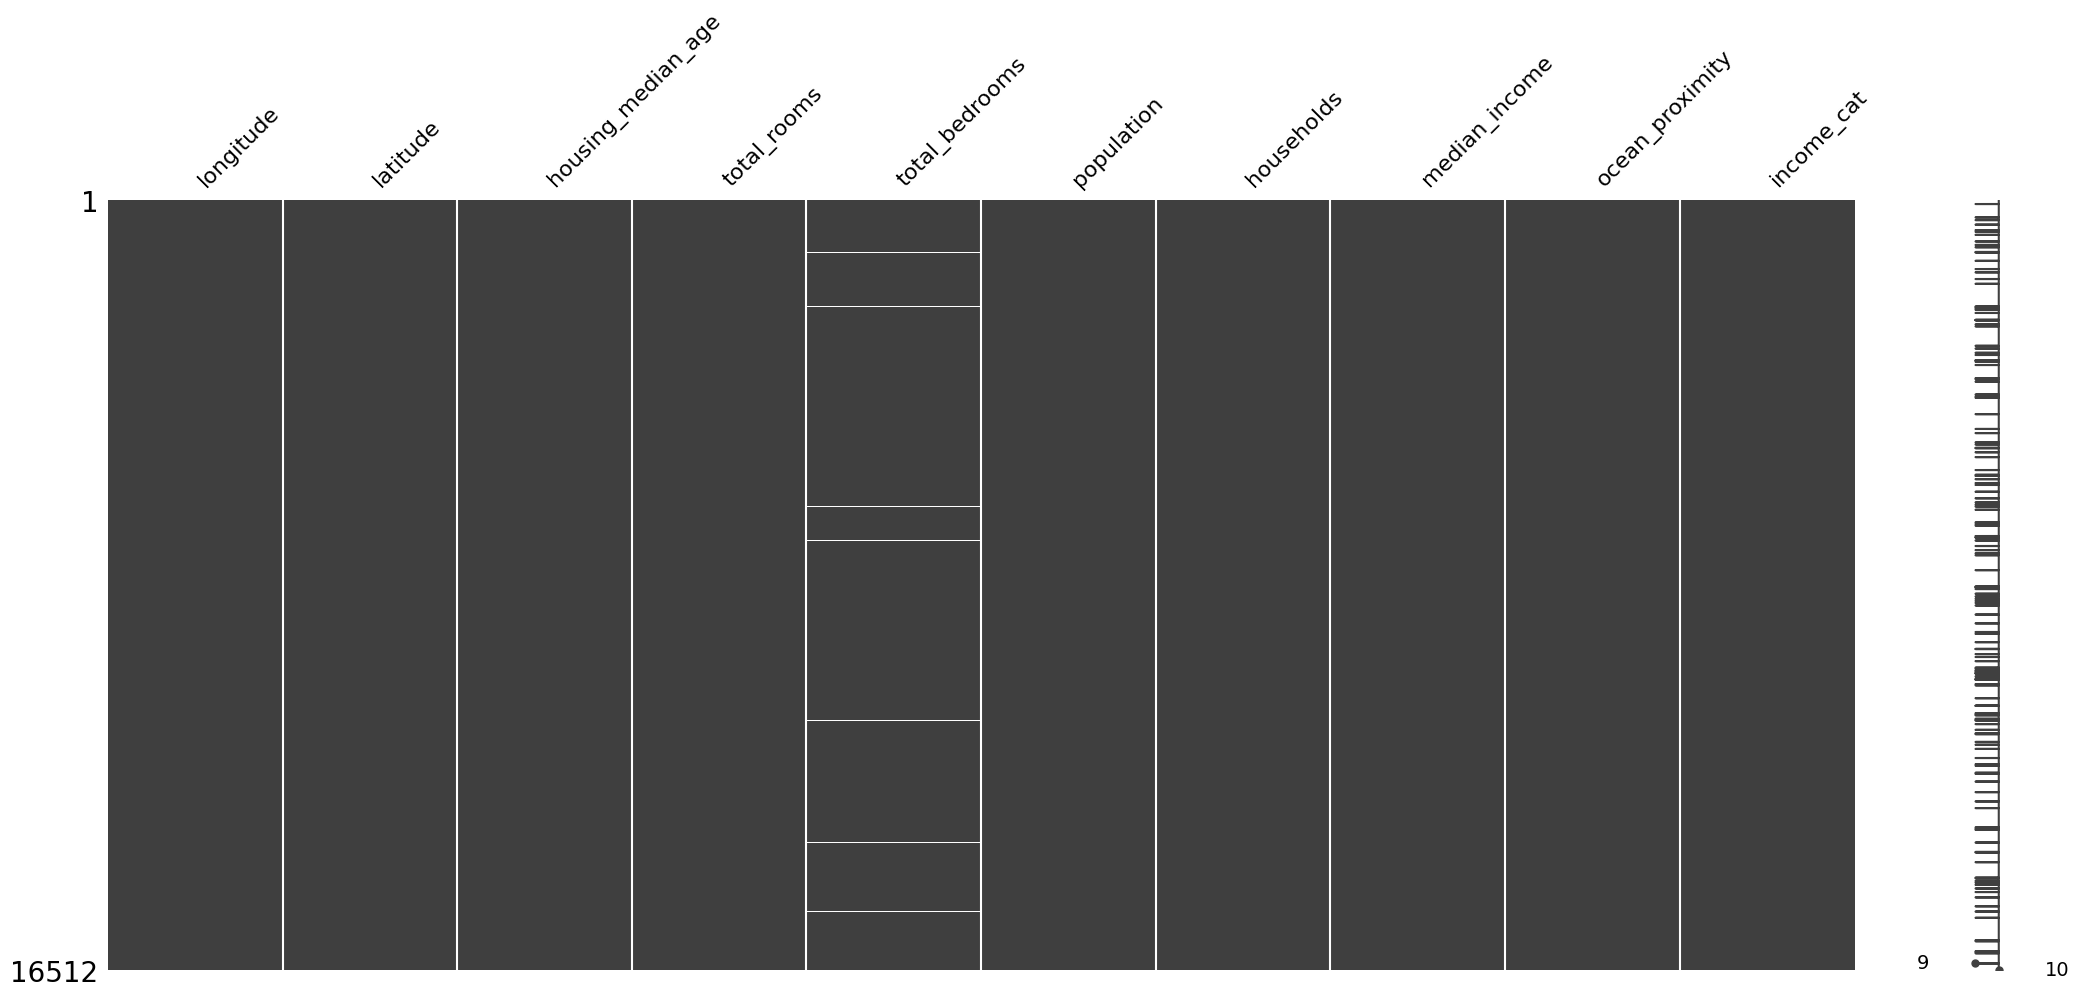

In [28]:
import missingno as msno

%matplotlib inline

msno.matrix(housing)
plt.show()

In [31]:
housing[housing.isnull().any(axis=1)]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
1606,-122.08,37.88,26.0,2947.0,NaN,825.0,626.0,2.9330,NEAR BAY,2
10915,-117.87,33.73,45.0,2264.0,NaN,1970.0,499.0,3.4193,<1H OCEAN,3
19150,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,<1H OCEAN,3
4186,-118.23,34.13,48.0,1308.0,NaN,835.0,294.0,4.2891,<1H OCEAN,3
16885,-122.40,37.58,26.0,3281.0,NaN,1145.0,480.0,6.3580,NEAR OCEAN,5
...,...,...,...,...,...,...,...,...,...,...
1350,-121.95,38.03,5.0,5526.0,NaN,3207.0,1012.0,4.0767,INLAND,3
4691,-118.37,34.07,50.0,2519.0,NaN,1117.0,516.0,4.3667,<1H OCEAN,3
9149,-118.50,34.46,17.0,10267.0,NaN,4956.0,1483.0,5.5061,<1H OCEAN,4
16757,-122.48,37.70,33.0,4492.0,NaN,3477.0,1537.0,3.0546,NEAR OCEAN,3
